# Day 2: E-commerce Clickstream Data Exploration

**Project:** E-commerce Conversion Intelligence Platform  
**Author:** Aishwarya Kadam  
**Date:** April 9, 2026  
**Dataset:** ecommerce_clickstream_transactions.csv  

## Objectives
1. Load and inspect the raw clickstream dataset
2. Profile data quality (missing values, duplicates, data types)
3. Identify event types and map them to funnel stages
4. Calculate baseline funnel metrics
5. Visualize event distributions
6. Document findings for downstream analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ Libraries loaded successfully!
Pandas version: 2.3.3
NumPy version: 2.3.4


In [2]:
# Load the raw dataset
file_path = '../data/raw/ecommerce_clickstream_transactions.csv'
df = pd.read_csv(file_path)

print(f"✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
Shape: 74,817 rows × 7 columns


## 1. First Look at the Data

Let's see what the raw data looks like.

In [3]:
# Show first 10 rows
df.head(10)

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome
0,1,1,2024-07-07 18:00:26.959902,page_view,NaN,NaN,NaN
1,1,1,2024-03-05 22:01:00.072000,page_view,NaN,NaN,NaN
2,1,1,2024-03-23 22:08:10.568453,product_view,prod_8199,NaN,NaN
3,1,1,2024-03-12 00:32:05.495638,add_to_cart,prod_4112,NaN,NaN
4,1,1,2024-02-25 22:43:01.318876,add_to_cart,prod_3354,NaN,NaN
5,1,1,2024-01-01 23:09:51.956825,page_view,NaN,NaN,NaN
6,1,1,2024-02-01 05:13:26.944169,add_to_cart,prod_4965,NaN,NaN
7,1,1,2024-02-14 15:41:53.071258,login,NaN,NaN,NaN
8,1,1,2024-05-20 23:13:38.011189,click,NaN,NaN,NaN
9,1,2,2024-06-27 16:17:34.523695,page_view,NaN,NaN,NaN


In [4]:
# Show last 10 rows
df.tail(10)

,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome
74807,1000,9,2024-03-20 02:45:31.128556,purchase,prod_9381,68.974008,purchase
74808,1000,9,2024-06-11 11:56:32.609591,logout,NaN,NaN,NaN
74809,1000,10,2024-01-12 15:56:53.525921,product_view,prod_4566,NaN,NaN
74810,1000,10,2024-07-13 15:30:59.991899,add_to_cart,prod_1899,NaN,NaN
74811,1000,10,2024-04-20 20:35:42.737664,purchase,prod_7326,248.268872,purchase
74812,1000,10,2024-05-11 22:48:45.500117,purchase,prod_1238,186.208225,purchase
74813,1000,10,2024-03-29 04:09:32.514318,logout,NaN,NaN,NaN
74814,1000,10,2024-02-09 02:58:56.128697,login,NaN,NaN,NaN
74815,1000,10,2024-04-30 16:19:48.002633,purchase,prod_2515,198.757849,purchase
74816,1000,10,2024-04-01 02:19:29.148727,logout,NaN,NaN,NaN


In [5]:
# Column info, data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74817 entries, 0 to 74816
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   UserID     74817 non-null  int64  
 1   SessionID  74817 non-null  int64  
 2   Timestamp  74817 non-null  object 
 3   EventType  74817 non-null  object 
 4   ProductID  32113 non-null  object 
 5   Amount     10682 non-null  float64
 6   Outcome    10682 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.0+ MB


## 2. Data Quality Profiling

Now let's check for data quality issues: missing values, duplicates, unique counts.

In [6]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing Count', ascending=False)

print("Missing Values Report:")
print("=" * 40)
print(missing_df)

Missing Values Report:
           Missing Count  Missing %
Amount             64135      85.72
Outcome            64135      85.72
ProductID          42704      57.08
UserID                 0       0.00
SessionID              0       0.00
Timestamp              0       0.00
EventType              0       0.00


In [7]:
# Check for duplicates
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates:,}")
print(f"Percentage of duplicates: {(total_duplicates/len(df)*100):.2f}%")

Total duplicate rows: 0
Percentage of duplicates: 0.00%


In [8]:
# Unique value counts for each column
print("Unique Values Per Column:")
print("=" * 40)
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col:20s}: {unique_count:,}")

Unique Values Per Column:
UserID              : 1,000
SessionID           : 10
Timestamp           : 74,817
EventType           : 7
ProductID           : 8,747
Amount              : 10,682
Outcome             : 1


## 3. Event Type Analysis

The `EventType` column is the heart of our funnel analysis. Let's understand what events exist and their distribution.

In [9]:
# Event type distribution
event_counts = df['EventType'].value_counts()
event_pcts = (df['EventType'].value_counts(normalize=True) * 100).round(2)

event_summary = pd.DataFrame({
    'Count': event_counts,
    'Percentage': event_pcts
})

print("Event Type Distribution:")
print("=" * 40)
print(event_summary)

Event Type Distribution:
              Count  Percentage
EventType                      
page_view     10819       14.46
add_to_cart   10735       14.35
product_view  10696       14.30
logout        10685       14.28
purchase      10682       14.28
click         10632       14.21
login         10568       14.13


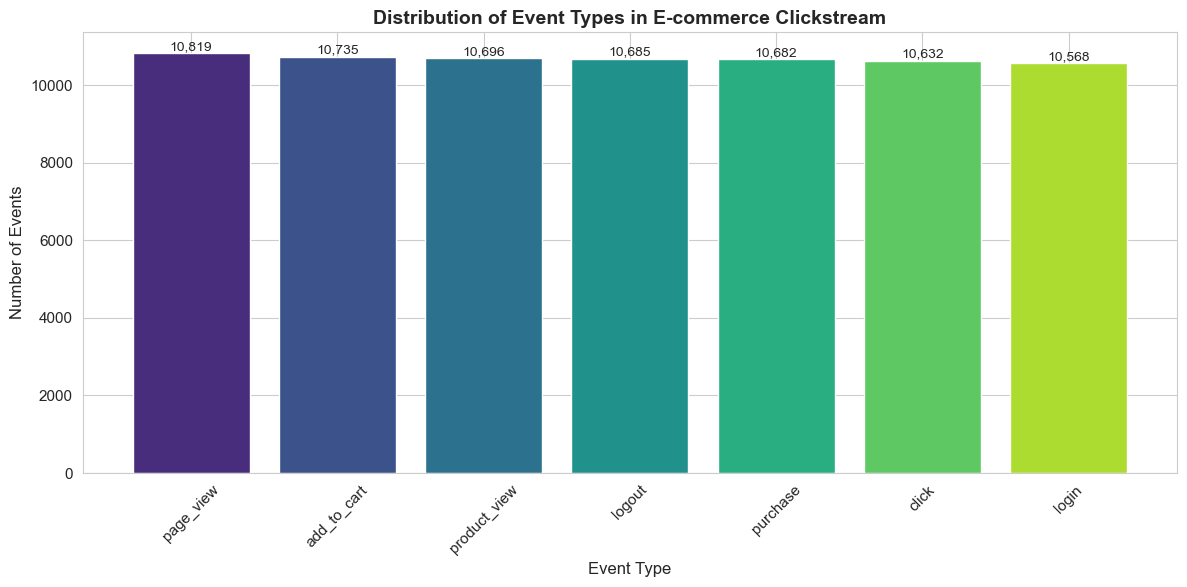

In [10]:
# Bar chart of event types
plt.figure(figsize=(12, 6))
colors = sns.color_palette('viridis', len(event_counts))
bars = plt.bar(event_counts.index, event_counts.values, color=colors)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10)

plt.title('Distribution of Event Types in E-commerce Clickstream', 
          fontsize=14, fontweight='bold')
plt.xlabel('Event Type', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Time Range Analysis

Let's understand the time period covered by the data.

In [11]:
# Convert timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Date range
print(f"Earliest event: {df['Timestamp'].min()}")
print(f"Latest event:   {df['Timestamp'].max()}")
print(f"Total span:     {(df['Timestamp'].max() - df['Timestamp'].min()).days} days")

Earliest event: 2024-01-01 00:01:35.004064
Latest event:   2024-07-24 10:13:04.983908
Total span:     205 days


In [12]:
# Add temporal features for analysis
df['date'] = df['Timestamp'].dt.date
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.day_name()
df['month'] = df['Timestamp'].dt.month_name()

print("✅ Added time features: date, hour, day_of_week, month")
df[['Timestamp', 'date', 'hour', 'day_of_week', 'month']].head()

✅ Added time features: date, hour, day_of_week, month


,Timestamp,date,hour,day_of_week,month
0,2024-07-07 18:00:26.959902,2024-07-07,18,Sunday,July
1,2024-03-05 22:01:00.072000,2024-03-05,22,Tuesday,March
2,2024-03-23 22:08:10.568453,2024-03-23,22,Saturday,March
3,2024-03-12 00:32:05.495638,2024-03-12,0,Tuesday,March
4,2024-02-25 22:43:01.318876,2024-02-25,22,Sunday,February


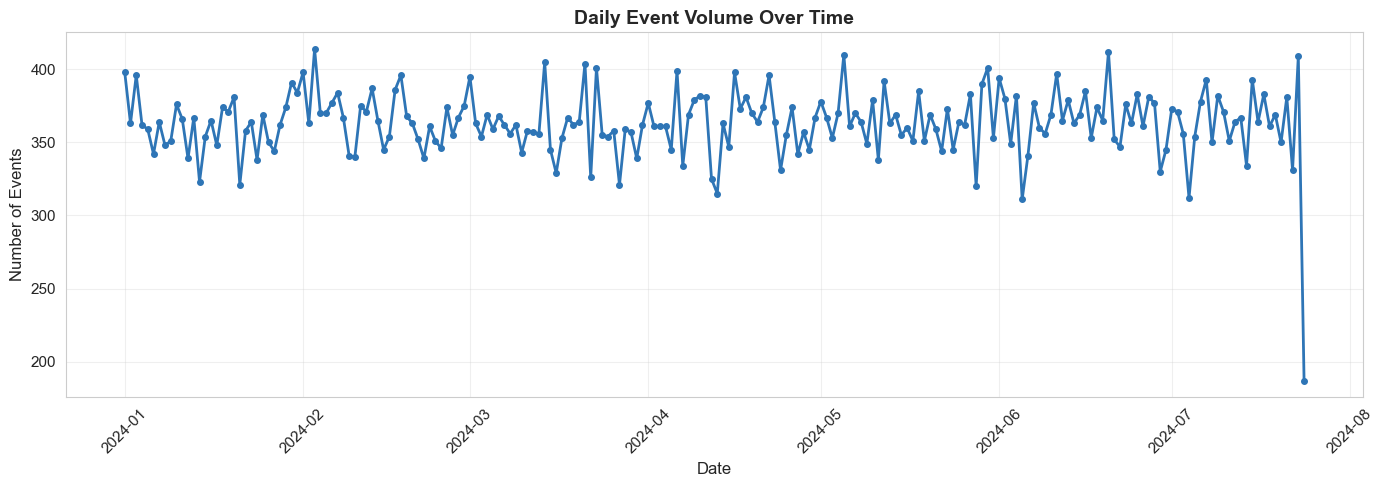

Average events per day: 363
Max events in one day:  414
Min events in one day:  187


In [13]:
# Daily event volume
daily_events = df.groupby('date').size()

plt.figure(figsize=(14, 5))
plt.plot(daily_events.index, daily_events.values, marker='o', 
         linewidth=2, markersize=4, color='#2E75B6')
plt.title('Daily Event Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average events per day: {daily_events.mean():.0f}")
print(f"Max events in one day:  {daily_events.max():,}")
print(f"Min events in one day:  {daily_events.min():,}")

## 5. User & Session Analysis

How active are users? How many sessions per user?

In [14]:
# User activity stats
user_stats = df.groupby('UserID').agg(
    total_events=('EventType', 'count'),
    sessions=('SessionID', 'nunique'),
    purchases=('EventType', lambda x: (x == 'purchase').sum())
).reset_index()

print("User Activity Summary:")
print("=" * 40)
print(f"Total unique users:     {df['UserID'].nunique():,}")
print(f"Total unique sessions:  {df['SessionID'].nunique():,}")
print(f"Avg events per user:    {user_stats['total_events'].mean():.1f}")
print(f"Avg sessions per user:  {user_stats['sessions'].mean():.1f}")
print(f"Users who purchased:    {(user_stats['purchases'] > 0).sum():,}")
print(f"Purchase rate:          {((user_stats['purchases'] > 0).sum() / len(user_stats) * 100):.2f}%")

User Activity Summary:
Total unique users:     1,000
Total unique sessions:  10
Avg events per user:    74.8
Avg sessions per user:  10.0
Users who purchased:    1,000
Purchase rate:          100.00%


## 6. Baseline Funnel Analysis

This is the core of our project. Let's calculate the basic conversion funnel:

**Funnel stages:**
1. **Page View** → User landed on the site
2. **Product View** → User looked at a product
3. **Add to Cart** → User added something to cart
4. **Purchase** → User completed a purchase

We'll calculate how many users reach each stage and the drop-off rate.

In [15]:
# Build user-level funnel
funnel_stages = ['page_view', 'product_view', 'add_to_cart', 'purchase']

# For each user, did they reach each stage?
user_funnel = df.groupby('UserID')['EventType'].apply(set).reset_index()
user_funnel.columns = ['UserID', 'events']

for stage in funnel_stages:
    user_funnel[stage] = user_funnel['events'].apply(lambda x: stage in x)

# Calculate funnel counts
funnel_counts = {stage: user_funnel[stage].sum() for stage in funnel_stages}

print("Funnel Analysis (User-level):")
print("=" * 50)
for i, stage in enumerate(funnel_stages):
    count = funnel_counts[stage]
    pct_total = (count / len(user_funnel) * 100)
    if i == 0:
        print(f"{stage:15s}: {count:,} users ({pct_total:.1f}% of all users)")
    else:
        prev_count = funnel_counts[funnel_stages[i-1]]
        drop_off = ((prev_count - count) / prev_count * 100) if prev_count > 0 else 0
        print(f"{stage:15s}: {count:,} users ({pct_total:.1f}% of all) | "
              f"Drop-off: {drop_off:.1f}%")

Funnel Analysis (User-level):
page_view      : 1,000 users (100.0% of all users)
product_view   : 1,000 users (100.0% of all) | Drop-off: 0.0%
add_to_cart    : 1,000 users (100.0% of all) | Drop-off: 0.0%
purchase       : 1,000 users (100.0% of all) | Drop-off: 0.0%


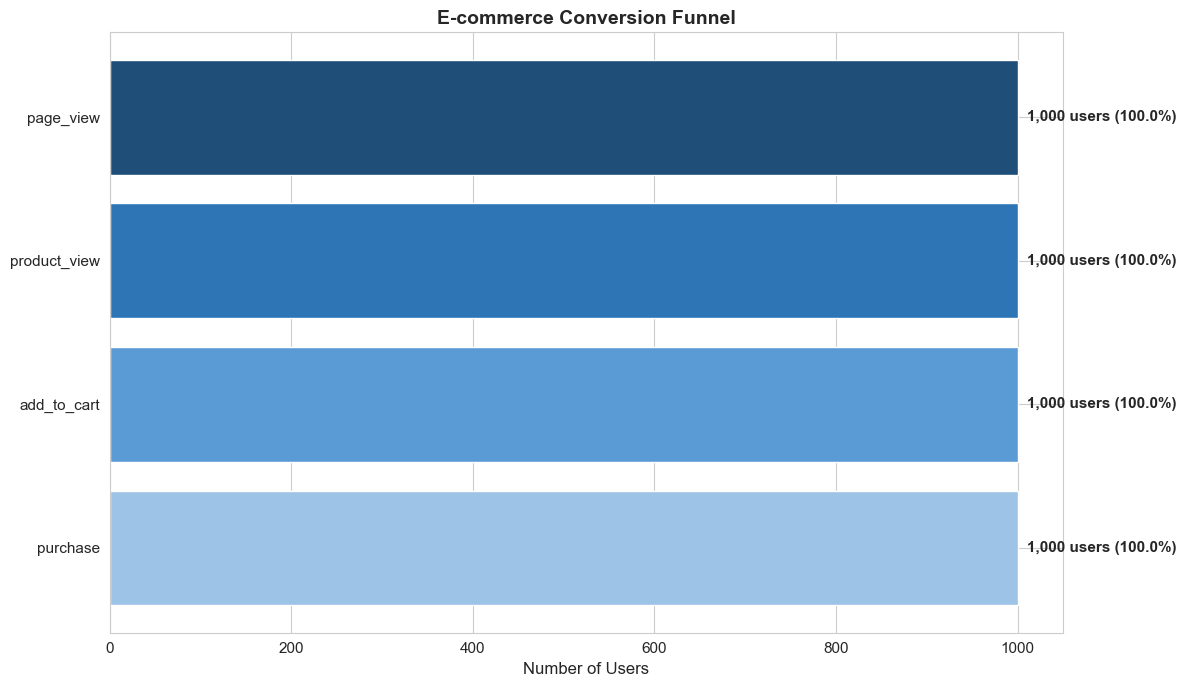

In [16]:
# Funnel visualization
fig, ax = plt.subplots(figsize=(12, 7))
stages = funnel_stages
values = [funnel_counts[s] for s in stages]
colors_funnel = ['#1F4E79', '#2E75B6', '#5B9BD5', '#9DC3E6']

bars = ax.barh(stages, values, color=colors_funnel)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    width = bar.get_width()
    pct = (val / values[0] * 100) if values[0] > 0 else 0
    ax.text(width + max(values)*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,} users ({pct:.1f}%)',
            ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Users', fontsize=12)
ax.set_title('E-commerce Conversion Funnel', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Conversion Rate Calculation

Let's compute the overall conversion rate and stage-by-stage conversion.

In [17]:
# Calculate conversion rates
total_users = funnel_counts['page_view']
purchasers = funnel_counts['purchase']

print("Conversion Rates:")
print("=" * 50)
print(f"Overall conversion (page_view → purchase): {(purchasers/total_users*100):.2f}%")
print()
print("Stage-by-stage conversion:")
print(f"  Page View → Product View: {(funnel_counts['product_view']/funnel_counts['page_view']*100):.2f}%")
print(f"  Product View → Add to Cart: {(funnel_counts['add_to_cart']/funnel_counts['product_view']*100):.2f}%")
print(f"  Add to Cart → Purchase: {(funnel_counts['purchase']/funnel_counts['add_to_cart']*100):.2f}%")

Conversion Rates:
Overall conversion (page_view → purchase): 100.00%

Stage-by-stage conversion:
  Page View → Product View: 100.00%
  Product View → Add to Cart: 100.00%
  Add to Cart → Purchase: 100.00%


## 8. Day-of-Week & Hour Analysis

When are users most active? When do conversions peak?

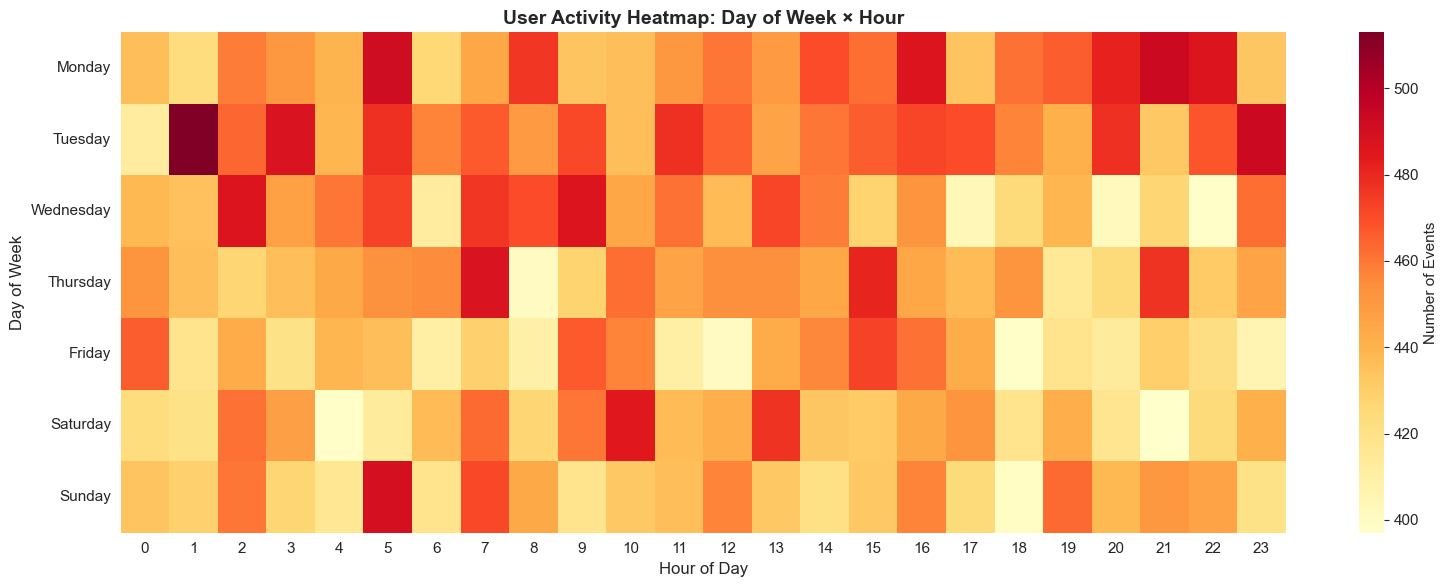

In [19]:
# Hour x Day of Week heatmap
heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, 
            cbar_kws={'label': 'Number of Events'})
plt.title('User Activity Heatmap: Day of Week × Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Revenue Analysis

For purchase events, let's analyze the Amount column.

In [21]:
# Filter to purchase events with valid amounts
purchases = df[(df['EventType'] == 'purchase') & (df['Amount'].notna())]

print("Revenue Analysis:")
print("=" * 50)
print(f"Total purchases:        {len(purchases):,}")
print(f"Total revenue:          ${purchases['Amount'].sum():,.2f}")
print(f"Average order value:    ${purchases['Amount'].mean():.2f}")
print(f"Median order value:     ${purchases['Amount'].median():.2f}")
print(f"Min purchase amount:    ${purchases['Amount'].min():.2f}")
print(f"Max purchase amount:    ${purchases['Amount'].max():.2f}")

Revenue Analysis:
Total purchases:        10,682
Total revenue:          $2,704,573.00
Average order value:    $253.19
Median order value:     $253.11
Min purchase amount:    $5.13
Max purchase amount:    $499.98


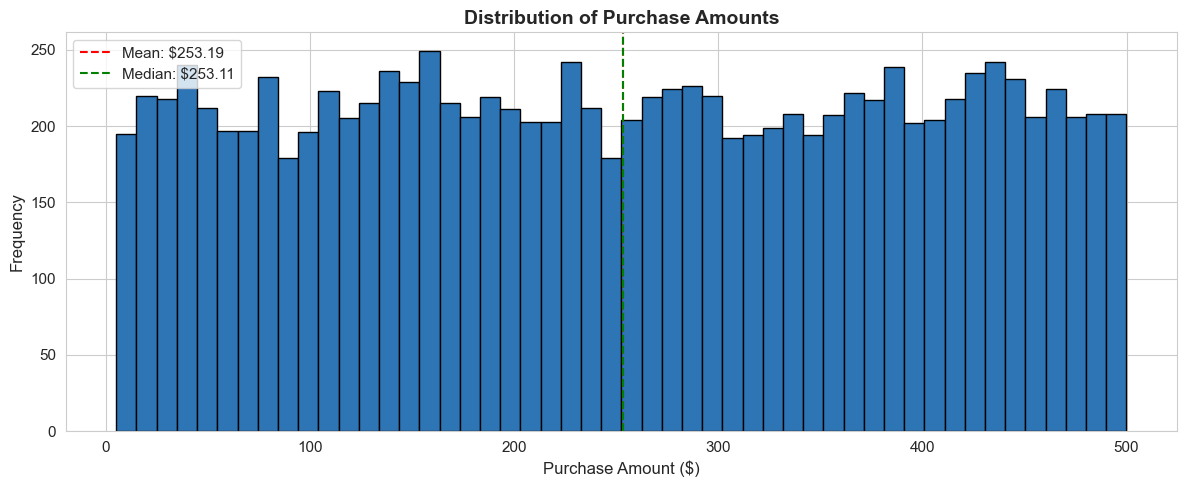

In [22]:
# Histogram of purchase amounts
plt.figure(figsize=(12, 5))
plt.hist(purchases['Amount'], bins=50, color='#2E75B6', edgecolor='black')
plt.title('Distribution of Purchase Amounts', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(purchases['Amount'].mean(), color='red', linestyle='--', 
            label=f"Mean: ${purchases['Amount'].mean():.2f}")
plt.axvline(purchases['Amount'].median(), color='green', linestyle='--', 
            label=f"Median: ${purchases['Amount'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Key Findings & Next Steps

### Summary of Findings

(I'll fill this in based on what I observe in the cells above)

### Data Quality Issues to Address
- 

### Insights for Funnel Optimization
- 

### Next Steps (Day 3)
- Build modular cleaning script (`src/transformation/cleaners.py`)
- Generate synthetic 2025 data to enrich the dataset
- Save cleaned data to `data/processed/`

In [23]:
# Save profile summary to a file
profile_summary = {
    'dataset_shape': df.shape,
    'date_range': f"{df['Timestamp'].min()} to {df['Timestamp'].max()}",
    'unique_users': df['UserID'].nunique(),
    'unique_sessions': df['SessionID'].nunique(),
    'unique_products': df['ProductID'].nunique(),
    'event_distribution': df['EventType'].value_counts().to_dict(),
    'funnel_counts': funnel_counts,
    'overall_conversion_rate': f"{(funnel_counts['purchase']/funnel_counts['page_view']*100):.2f}%",
    'total_revenue': f"${purchases['Amount'].sum():,.2f}",
    'avg_order_value': f"${purchases['Amount'].mean():.2f}"
}

import json
with open('../docs/day2_profile_summary.json', 'w') as f:
    json.dump(profile_summary, f, indent=2, default=str)

print("✅ Profile summary saved to docs/day2_profile_summary.json")
print()
print("Day 2 exploration complete! 🎉")

✅ Profile summary saved to docs/day2_profile_summary.json

Day 2 exploration complete! 🎉


In [25]:
# Display key findings for Day 2 review
import json

with open('../docs/day2_profile_summary.json', 'r') as f:
    summary = json.load(f)

print("=" * 60)
print("DAY 2 KEY FINDINGS - QUICK SUMMARY")
print("=" * 60)
print(f"Total rows:           {summary['dataset_shape']}")
print(f"Date range:           {summary['date_range']}")
print(f"Unique users:         {summary['unique_users']:,}")
print(f"Unique sessions:      {summary['unique_sessions']:,}")
print(f"Unique products:      {summary['unique_products']:,}")
print()
print("FUNNEL METRICS:")
for stage, count in summary['funnel_counts'].items():
    # Convert count to int in case it's a string
    count_int = int(count)
    print(f"  {stage:15s}: {count_int:,} users")
print()
print(f"Overall conversion:   {summary['overall_conversion_rate']}")
print(f"Total revenue:        {summary['total_revenue']}")
print(f"Avg order value:      {summary['avg_order_value']}")
print("=" * 60)

DAY 2 KEY FINDINGS - QUICK SUMMARY
Total rows:           [74817, 11]
Date range:           2024-01-01 00:01:35.004064 to 2024-07-24 10:13:04.983908
Unique users:         1,000
Unique sessions:      10
Unique products:      8,747

FUNNEL METRICS:
  page_view      : 1,000 users
  product_view   : 1,000 users
  add_to_cart    : 1,000 users
  purchase       : 1,000 users

Overall conversion:   100.00%
Total revenue:        $2,704,573.00
Avg order value:      $253.19
